In [ ]:
import pandas as pd

# --- Placeholder for the combined survey file path ---
# IMPORTANT: Replace '/content/combined_surveys.xlsx' with the actual path to your combined Excel file.
COMBINED_SURVEY_FILE_PATH = '/content/FRTf20_surveys.xlsx'

# --- Load the combined survey file ---
df_all_surveys = None
try:
    df_all_surveys = pd.read_excel(COMBINED_SURVEY_FILE_PATH)
    print(f"Successfully loaded '{COMBINED_SURVEY_FILE_PATH}'")

    # Rename columns if necessary (this dictionary handles potential raw or already cleaned names)
    new_column_names = {
        'Pozo': 'WELL_NAME', # Added to correctly identify well name
        'MD\n(ft)': 'MD (ft)',
        'Incl\n(°)': 'Inclination (°)',
        'Azim Grid\n(°)': 'Azimuth Grid (°)',
        'TVD\n(ft)': 'TVD (ft)',
        'TVDSS\n(ft)': 'TVDSS (ft)',
        'VSEC\n(ft)': 'VSEC (ft)',
        'NS\n(N/S ft)': 'NS (N/S ft)',
        'EW\n(E/W ft)': 'EW (E/W ft)',
        'DLS\n(°/100ft)': 'DLS (°/100ft)'
    }
    # Apply renaming only for columns that exist in the DataFrame
    df_all_surveys.rename(columns={k: v for k, v in new_column_names.items() if k in df_all_surveys.columns}, inplace=True)


    # Identify unique wells and print them
    if 'WELL_NAME' in df_all_surveys.columns:
        unique_wells_in_file = df_all_surveys['WELL_NAME'].unique().tolist()
        print(f"Pozos identificados en '{COMBINED_SURVEY_FILE_PATH}': {unique_wells_in_file}")
        print("\nTabla de Pozos:")
        display(df_all_surveys[['WELL_NAME']].drop_duplicates().reset_index(drop=True))
    else:
        print(f"Warning: 'WELL_NAME' column not found in '{COMBINED_SURVEY_FILE_PATH}'. Please ensure your combined survey file has a 'WELL_NAME' column. Assigning a default well name.")
        df_all_surveys['WELL_NAME'] = 'UNKNOWN_WELL' # Assign a default if not found

    # Ensure numeric columns are of the correct type
    # Exclude 'NS (N/S ft)' and 'EW (E/W ft)' from initial numeric conversion
    # as they contain directional indicators that will be parsed later in this cell.
    numeric_cols_for_initial_conversion = [
        'MD (ft)', 'Inclination (°)', 'Azimuth Grid (°)', 'TVD (ft)',
        'TVDSS (ft)', 'VSEC (ft)', 'DLS (°/100ft)'
    ]
    for col in numeric_cols_for_initial_conversion:
        if col in df_all_surveys.columns:
            df_all_surveys[col] = pd.to_numeric(df_all_surveys[col], errors='coerce')

    # --- Integrate Coordinate Conversion for NS (N/S ft) and EW (E/W ft) ---
    # Function to convert N/S column, handling both numeric values and string values with directional indicators
    def convert_ns_coordinate(value):
        s_value = str(value).strip().upper().replace(',', '.')
        try:
            # First, try to convert directly to float (handles already numeric values or numeric strings)
            return float(s_value)
        except ValueError:
            # If direct conversion fails, check for S/N suffixes
            if 'S' in s_value:
                try:
                    return -float(s_value.replace('S', '').strip())
                except ValueError:
                    return None
            elif 'N' in s_value:
                try:
                    return float(s_value.replace('N', '').strip())
                except ValueError:
                    return None
            else: # If no S/N and direct conversion failed, return None
                return None

    # Function to convert E/W column, handling both numeric values and string values with directional indicators
    def convert_ew_coordinate(value):
        s_value = str(value).strip().upper().replace(',', '.')
        try:
            # First, try to convert directly to float (handles already numeric values or numeric strings)
            return float(s_value)
        except ValueError:
            # If direct conversion fails, check for E/W suffixes
            if 'W' in s_value:
                try:
                    return -float(s_value.replace('W', '').strip())
                except ValueError:
                    return None
            elif 'E' in s_value:
                try:
                    return float(s_value.replace('E', '').strip())
                except ValueError:
                    return None
            else: # If no E/W and direct conversion failed, return None
                return None

    # Apply the conversion functions to the corresponding columns if they exist
    if 'NS (N/S ft)' in df_all_surveys.columns:
        df_all_surveys['NS_ft'] = df_all_surveys['NS (N/S ft)'].apply(convert_ns_coordinate)
        print("Column 'NS_ft' created and converted to numeric, handling N/S indicators if present.")
    else:
        print("Warning: 'NS (N/S ft)' column not found. Cannot create 'NS_ft'.")

    if 'EW (E/W ft)' in df_all_surveys.columns:
        df_all_surveys['EW_ft'] = df_all_surveys['EW (E/W ft)'].apply(convert_ew_coordinate)
        print("Column 'EW_ft' created and converted to numeric, handling E/W indicators if present.")
    else:
        print("Warning: 'EW (E/W ft)' column not found. Cannot create 'EW_ft'.")


except FileNotFoundError:
    print(f"Error: '{COMBINED_SURVEY_FILE_PATH}' not found. Please ensure it's in the /content/ directory.")
    df_all_surveys = None
except Exception as e:
    print(f"Error processing '{COMBINED_SURVEY_FILE_PATH}': {e}")
    df_all_surveys = None


# --- Load 'Topes_y_BSy.xlsx' for tops data ---
df_topes = None
try:
    df_topes = pd.read_excel('/content/Topes_y_BS_FRTf20.xlsx')
    print("Successfully loaded 'Topes_y_BS.xlsx'")
    if df_topes is not None:
        df_topes['MD (ft)'] = pd.to_numeric(df_topes['MD (ft)'], errors='coerce')
except FileNotFoundError:
    print("Error: 'Topes_y_BS.xlsx' not found. Please ensure it's in the /content/ directory.")
except Exception as e:
    print(f"Error loading 'Topes_y_BS.xlsx': {e}")


# --- Load 'BS' sheet from 'Topes_y_BSy.xlsx' for casings data ---
df_casings = None
try:
    df_casings = pd.read_excel('/content/Topes_y_BS_FRTf20.xlsx', sheet_name='BS')
    print("Successfully loaded 'BS' sheet from 'Topes_y_BSy.xlsx'")
    if df_casings is not None:
        # Columna 'Sección' para el nombre de la sección, columna 'MD' para la profundidad
        if 'Sección' in df_casings.columns and 'MD' in df_casings.columns:
            df_casings = df_casings[['Sección', 'MD']].copy() # Use .copy() to avoid SettingWithCopyWarning
            df_casings.columns = ['SECTION_NAME', 'MD (ft)']
            df_casings['MD (ft)'] = pd.to_numeric(df_casings['MD (ft)'], errors='coerce')
            df_casings = df_casings.dropna(subset=['MD (ft)']) # Eliminar filas con profundidades nulas
        else:
            print("Expected columns ('Sección' or 'MD') not found in 'BS' sheet for df_casings.")
except FileNotFoundError:
    print("Error: 'Topes_y_BSy.xlsx' not found. Please ensure it's in the /content/ directory.")
except Exception as e:
    print(f"Error loading 'BS' sheet for casings: {e}")

Successfully loaded '/content/FRTf20_surveys.xlsx'
Pozos identificados en '/content/FRTf20_surveys.xlsx': ['FRTf20']

Tabla de Pozos:


,WELL_NAME
0,FRTf20


Column 'NS_ft' created and converted to numeric, handling N/S indicators if present.
Column 'EW_ft' created and converted to numeric, handling E/W indicators if present.
Successfully loaded 'Topes_y_BS.xlsx'
Successfully loaded 'BS' sheet from 'Topes_y_BSy.xlsx'


### Preparación de Datos y Gráficos de Trayectoria

Primero, vamos a limpiar los nombres de las columnas del dataframe `df_florena` para que sean más intuitivos. Luego, generaremos los gráficos de inclinación y azimut en función de la Profundidad Vertical Verdadera (TVD), con el eje Y invertido para simular la profundidad en un pozo. También agregaremos líneas horizontales que representen las profundidades de los topes del dataframe `df_topes`.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The column renaming for survey data is now handled in the first cell.
# This cell now only ensures df_topes has correct types.

if df_topes is not None:
    df_topes['MD(ft)'] = pd.to_numeric(df_topes['MD (ft)'], errors='coerce')

print("\nData preparation completed.")


Data preparation completed.


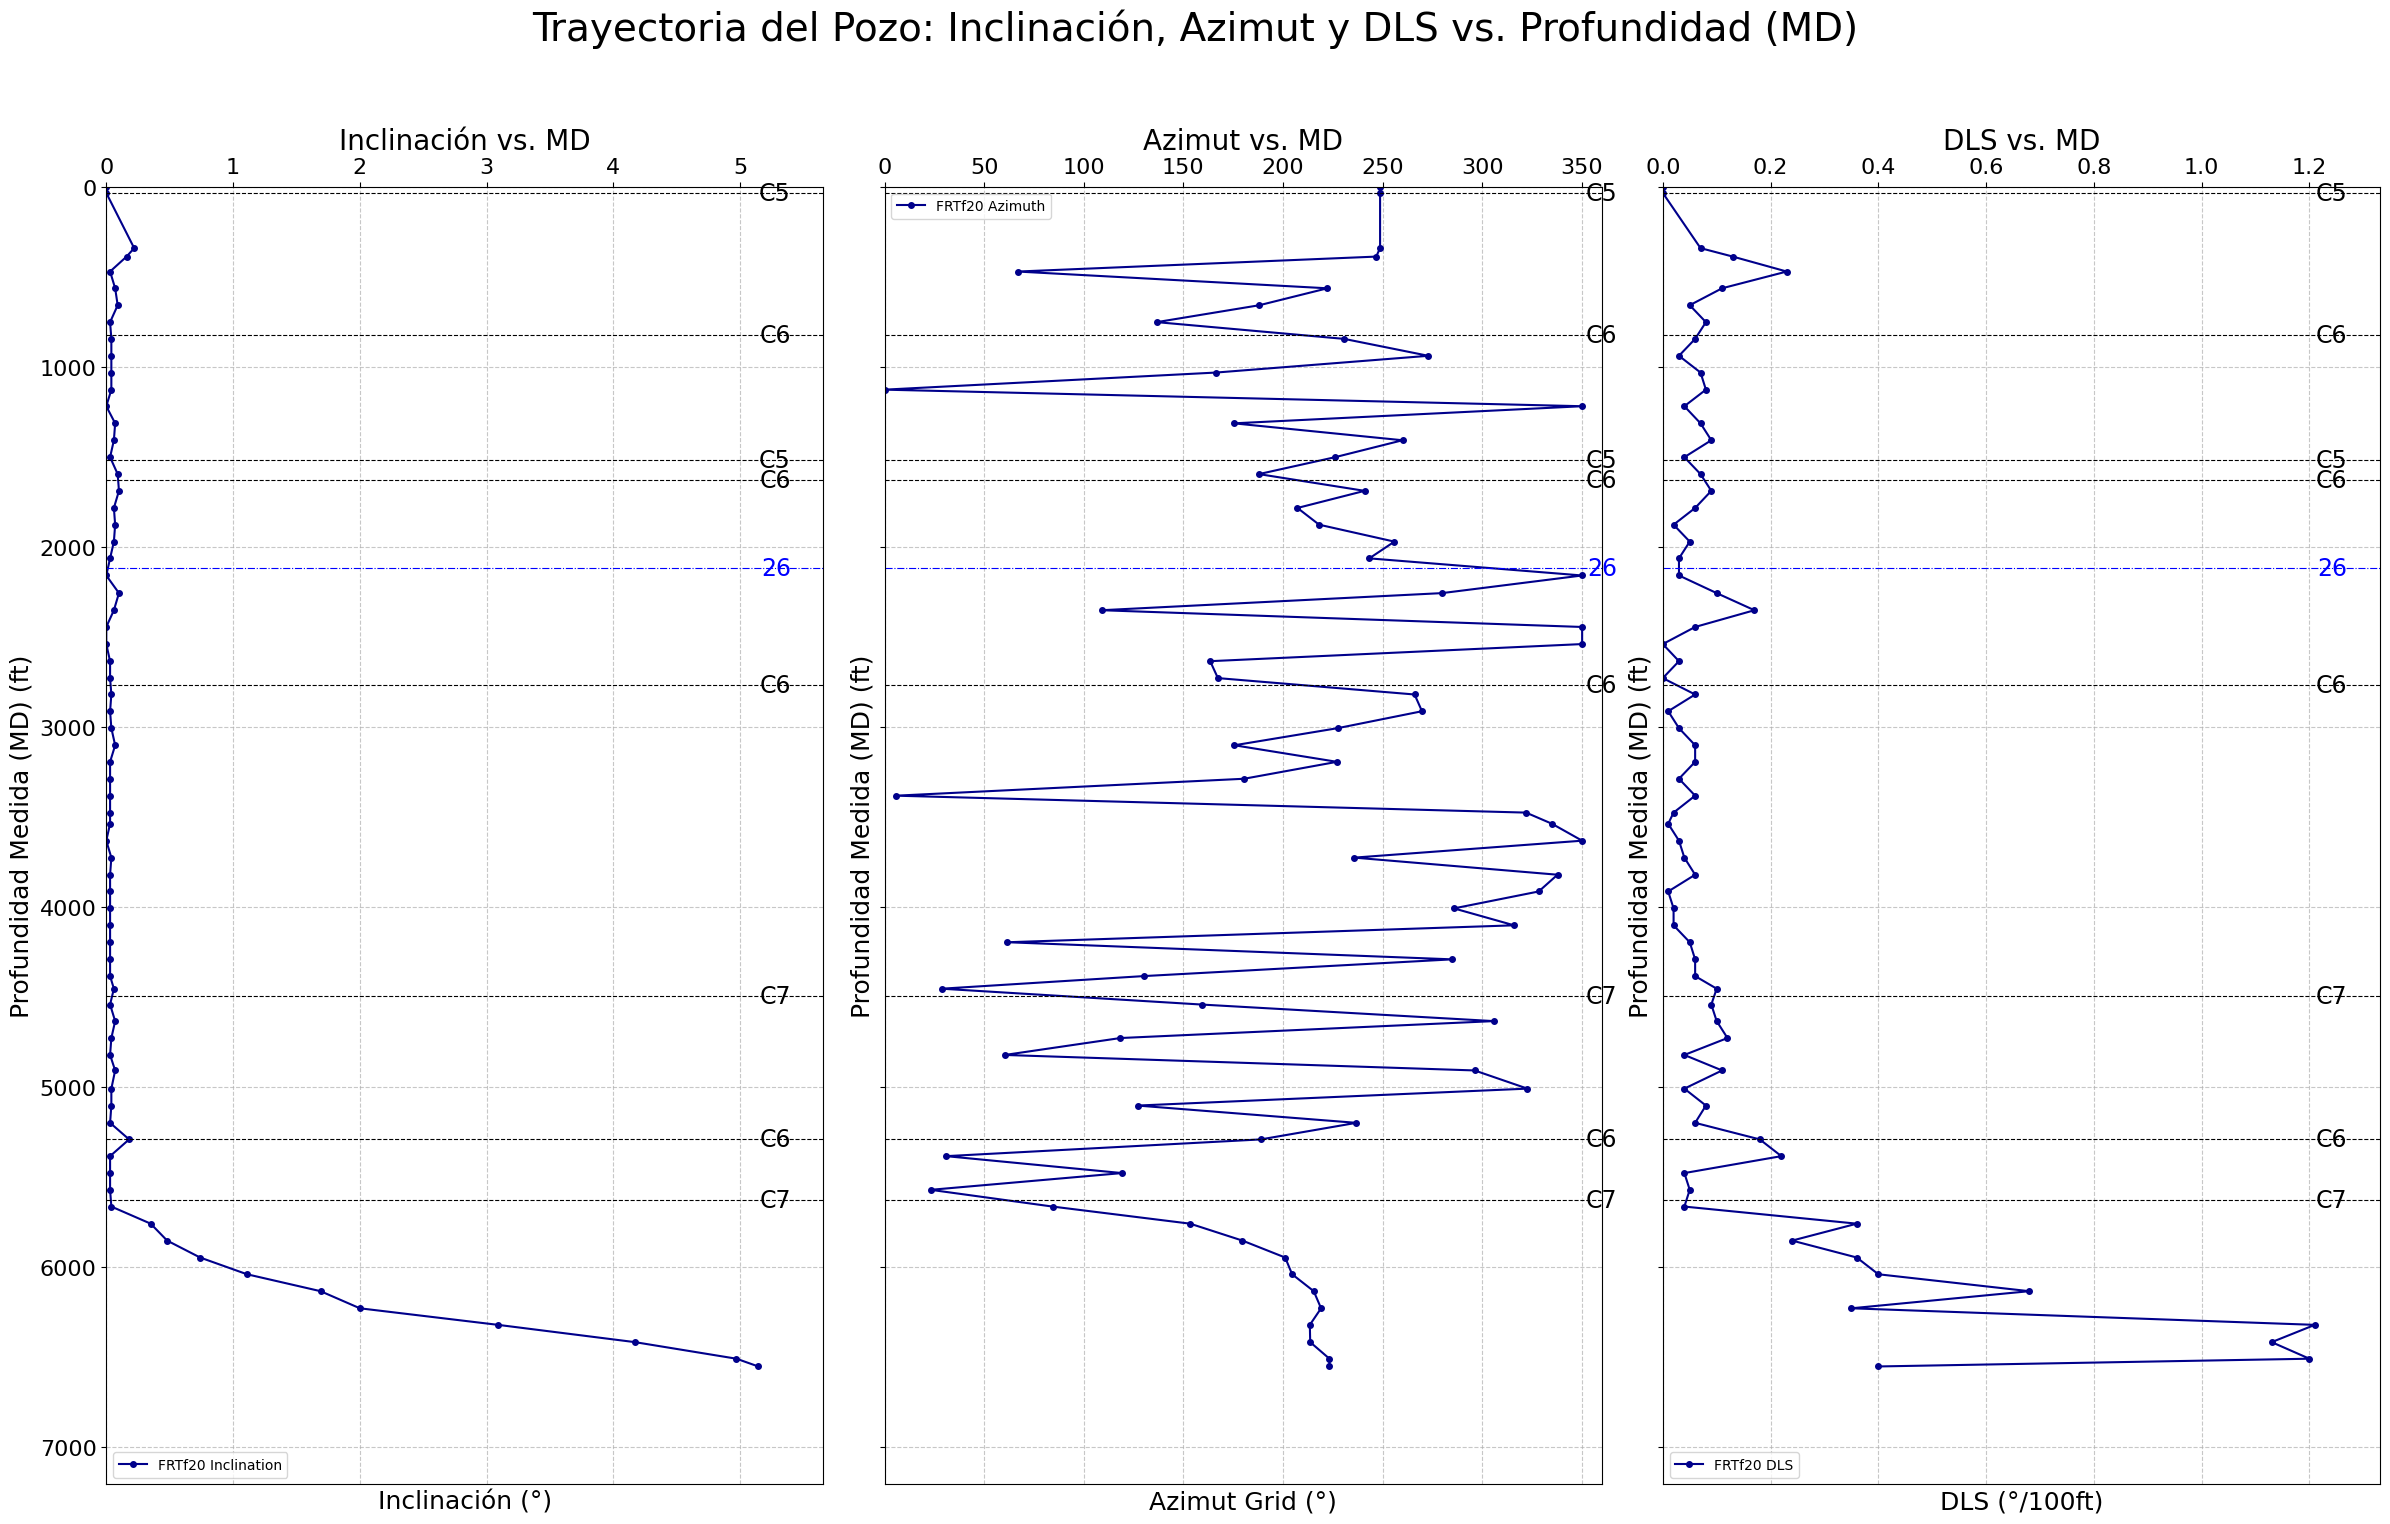

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# --- Configuración de Pozos para Graficar en esta celda ---
# Define aquí el nombre del pozo o pozos que quieres incluir en esta gráfica.
# Por ejemplo: wells_to_plot_this_cell = ['FRUf19', 'FRUf19y']
# Por defecto, grafica todos los pozos disponibles en df_all_surveys.
wells_to_plot_this_cell = ['FRTf20']

# --- Preparación del DataFrame para esta celda ---
df_current_plot = None
if 'df_all_surveys' in locals() and df_all_surveys is not None and not df_all_surveys.empty:
    if 'WELL_NAME' in df_all_surveys.columns:
        if wells_to_plot_this_cell: # Si se seleccionan pozos específicos
            df_current_plot = df_all_surveys[df_all_surveys['WELL_NAME'].isin(wells_to_plot_this_cell)].copy()
        else: # Si la lista está vacía o no se especifican pozos, graficar todos los pozos disponibles
            df_current_plot = df_all_surveys.copy()
        if df_current_plot.empty and wells_to_plot_this_cell: # Si se seleccionaron pozos pero no se encontraron
            print(f"Advertencia: Ninguno de los pozos seleccionados '{wells_to_plot_this_cell}' fue encontrado en los datos. No se generará el gráfico.")
            df_current_plot = None # Asegurar que es None si no hay datos
        elif df_current_plot.empty: # Si df_all_surveys estaba vacío
            print("Advertencia: 'df_all_surveys' está vacío. No se pueden generar los gráficos.")
            df_current_plot = None
    else:
        print("Advertencia: La columna 'WELL_NAME' no se encuentra en 'df_all_surveys'. Se intentará graficar todos los datos disponibles sin filtrar por pozo.")
        df_current_plot = df_all_surveys.copy()
else:
    print("Error: 'df_all_surveys' no está cargado o está vacío. No se pueden generar los gráficos.")


if df_current_plot is not None and not df_current_plot.empty:
    # Define los límites para las escalas (puedes ajustar estos valores)
    # Por defecto, se toman los rangos de los datos existentes.
    min_md_limit = 0 # Profundidad mínima por defecto
    max_md_limit = df_current_plot['MD (ft)'].max() * 1.1 # Adjust max_md_limit dynamically

    inclination_xlim = (0, df_current_plot['Inclination (°)'].max() * 1.1) # Límites por defecto para Inclinación
    azimuth_xlim = (0, 360) # Límites por defecto para Azimut

    # Manejar DLS con posibles valores negativos
    dls_min = df_current_plot['DLS (°/100ft)'].min()
    dls_max = df_current_plot['DLS (°/100ft)'].max()
    dls_xlim = (dls_min * 1.1 if dls_min < 0 else 0, dls_max * 1.1) # Límites por defecto para DLS

    fig, axes = plt.subplots(1, 3, figsize=(24, 16), sharey=True);
    fig.suptitle('Trayectoria del Pozo: Inclinación, Azimut y DLS vs. Profundidad (MD)', fontsize=28) # Título general aumentado

    unique_wells = df_current_plot['WELL_NAME'].unique()
    # Define una lista de colores oscuros preferidos para los primeros pozos.
    preferred_dark_colors = ['darkblue', 'darkred', 'darkgreen', 'purple', 'brown', 'teal', 'darkgoldenrod', 'indigo', 'maroon', 'darkslategray']

    colors_for_plotting = []
    for i, well_name in enumerate(unique_wells):
        if i < len(preferred_dark_colors):
            colors_for_plotting.append(preferred_dark_colors[i])
        else:
            # Para pozos más allá de la lista predefinida, usa un colormap con sesgo hacia tonos más oscuros.
            cmap_val = (i - len(preferred_dark_colors)) / (len(unique_wells) - len(preferred_dark_colors) + 1e-6) # Normalizar el índice
            colors_for_plotting.append(plt.cm.get_cmap('gist_ncar')(cmap_val * 0.6 + 0.1)) # Ajustar el rango para ser más oscuro

    for i, well_name in enumerate(unique_wells):
        df_well = df_current_plot[df_current_plot['WELL_NAME'] == well_name]
        color = colors_for_plotting[i]

        # Plot de Inclinación
        axes[0].plot(df_well['Inclination (°)'], df_well['MD (ft)'], color=color, marker='o', markersize=4, label=f'{well_name} Inclination')

        # Plot de Azimut
        axes[1].plot(df_well['Azimuth Grid (°)'], df_well['MD (ft)'], color=color, marker='o', markersize=4, label=f'{well_name} Azimuth')

        # Nuevo Plot de DLS
        axes[2].plot(df_well['DLS (°/100ft)'], df_well['MD (ft)'], color=color, marker='o', markersize=4, label=f'{well_name} DLS')

    # Common settings for all plots
    for ax in axes:
        ax.set_ylabel('Profundidad Medida (MD) (ft)', fontsize=18)
        ax.invert_yaxis()
        ax.set_ylim(max_md_limit, min_md_limit)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.tick_params(axis='x', labelsize=16, top=True, labeltop=True, bottom=False, labelbottom=False)
        ax.tick_params(axis='y', labelsize=16)

        # Añadir líneas horizontales para los topes (condicional)
        if df_topes is not None:
            for _, row in df_topes.iterrows():
                if min_md_limit <= row['MD (ft)'] <= max_md_limit:
                    color_tope = 'darkred' if row['TOPS'] == 'KOP' else 'black'
                    ax.axhline(y=row['MD (ft)'], color=color_tope, linestyle='--', linewidth=0.8)
                    ax.text(ax.get_xlim()[1], row['MD (ft)'], row['TOPS'], color=color_tope, verticalalignment='center', horizontalalignment='right', fontsize=17)

        # Añadir líneas horizontales para los revestimientos (condicional)
        if df_casings is not None:
            for _, row in df_casings.iterrows():
                if min_md_limit <= row['MD (ft)'] <= max_md_limit:
                    ax.axhline(y=row['MD (ft)'], color='blue', linestyle='-.', linewidth=0.8)
                    ax.text(ax.get_xlim()[1], row['MD (ft)'], row['SECTION_NAME'], color='blue', verticalalignment='center', horizontalalignment='right', fontsize=17)

    axes[0].set_title('Inclinación vs. MD', fontsize=20)
    axes[0].set_xlabel('Inclinación (°)', fontsize=18)
    axes[0].set_xlim(inclination_xlim)
    axes[0].legend()

    axes[1].set_title('Azimut vs. MD', fontsize=20)
    axes[1].set_xlabel('Azimut Grid (°)', fontsize=18)
    axes[1].set_xlim(azimuth_xlim)
    axes[1].legend()

    axes[2].set_title('DLS vs. MD', fontsize=20)
    axes[2].set_xlabel('DLS (°/100ft)', fontsize=18)
    axes[2].set_xlim(dls_xlim)
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No se pueden generar los gráficos porque el dataframe 'df_current_plot' no se cargó correctamente o está vacío (posiblemente debido a que las columnas 'MD (ft)', 'Inclination (°)', 'Azimuth Grid (°)' o 'DLS (°/100ft)' no existen o los pozos seleccionados no se encontraron).")

### Gráfico de Vista en Planta



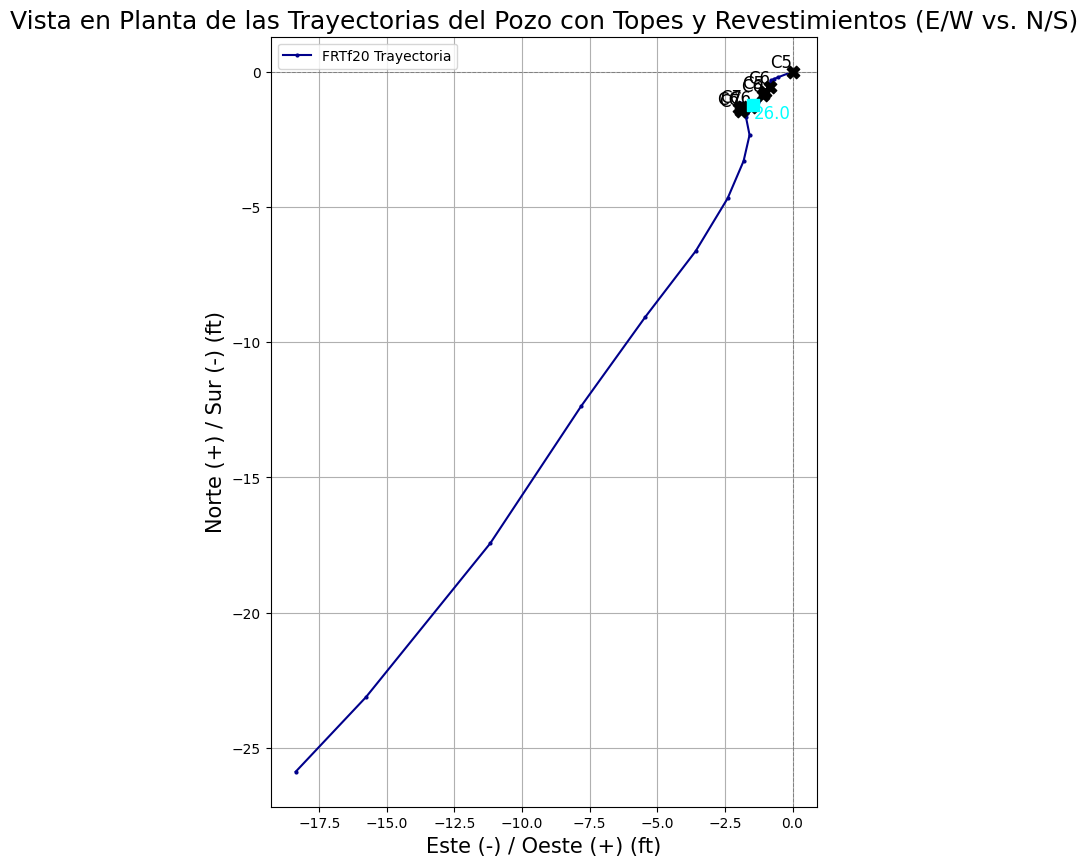

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuración de Pozos para Graficar en esta celda ---
# Define aquí el nombre del pozo o pozos que quieres incluir en esta gráfica.
# Por ejemplo: wells_to_plot_this_cell = ['FRUf19', 'FRUf19y']
# Por defecto, grafica todos los pozos disponibles en df_all_surveys.
wells_to_plot_this_cell = ['FRTf20']

# --- Preparación del DataFrame para esta celda ---
df_current_plot = None
if 'df_all_surveys' in locals() and df_all_surveys is not None and not df_all_surveys.empty:
    if 'WELL_NAME' in df_all_surveys.columns:
        if wells_to_plot_this_cell: # Si se seleccionan pozos específicos
            df_current_plot = df_all_surveys[df_all_surveys['WELL_NAME'].isin(wells_to_plot_this_cell)].copy()
        else: # Si la lista está vacía o no se especifican pozos, graficar todos los pozos disponibles
            df_current_plot = df_all_surveys.copy()
        if df_current_plot.empty and wells_to_plot_this_cell: # Si se seleccionaron pozos pero no se encontraron
            print(f"Advertencia: Ninguno de los pozos seleccionados '{wells_to_plot_this_cell}' fue encontrado en los datos. No se generará el gráfico.")
            df_current_plot = None # Asegurar que es None si no hay datos
        elif df_current_plot.empty: # Si df_all_surveys estaba vacío
            print("Advertencia: 'df_all_surveys' está vacío. No se pueden generar los gráficos.")
            df_current_plot = None
    else:
        print("Advertencia: La columna 'WELL_NAME' no se encuentra en 'df_all_surveys'. Se intentará graficar todos los datos disponibles sin filtrar por pozo.")
        df_current_plot = df_all_surveys.copy()
else:
    print("Error: 'df_all_surveys' no está cargado o está vacío. No se pueden generar los gráficos.")


if df_current_plot is not None and 'NS_ft' in df_current_plot.columns and 'EW_ft' in df_current_plot.columns and not df_current_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 10)) # Increased figure size and get ax object

    unique_wells = df_current_plot['WELL_NAME'].unique()
    # Define una lista de colores oscuros preferidos para los primeros pozos.
    preferred_dark_colors = ['darkblue', 'darkred', 'darkgreen', 'purple', 'brown', 'teal', 'darkgoldenrod', 'indigo', 'maroon', 'darkslategray']

    colors_for_plotting = []
    for i, well_name in enumerate(unique_wells):
        if i < len(preferred_dark_colors):
            colors_for_plotting.append(preferred_dark_colors[i])
        else:
            # Para pozos más allá de la lista predefinida, usa un colormap con sesgo hacia tonos más oscuros.
            cmap_val = (i - len(preferred_dark_colors)) / (len(unique_wells) - len(preferred_dark_colors) + 1e-6) # Normalizar el índice
            colors_for_plotting.append(plt.cm.get_cmap('gist_ncar')(cmap_val * 0.6 + 0.1)) # Ajustar el rango para ser más oscuro

    for i, well_name in enumerate(unique_wells):
        df_well = df_current_plot[df_current_plot['WELL_NAME'] == well_name]
        color = colors_for_plotting[i]
        ax.plot(df_well['EW_ft'], df_well['NS_ft'], color=color, marker='o', markersize=2, linestyle='-', label=f'{well_name} Trayectoria')

    # --- Interpolate and plot Tops ---
    if df_topes is not None and not df_topes.empty:
        # Ensure MD (ft) in df_current_plot is sorted for interpolation
        df_current_plot_sorted = df_current_plot.sort_values(by='MD (ft)').reset_index(drop=True)

        # Check if NS_ft and EW_ft exist in df_current_plot_sorted
        if 'NS_ft' in df_current_plot_sorted.columns and 'EW_ft' in df_current_plot_sorted.columns:
            df_topes_for_interp = df_topes.copy()
            if len(df_current_plot_sorted['MD (ft)']) > 1:
                df_topes_for_interp['NS_ft_interp'] = np.interp(df_topes_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['NS_ft'])
                df_topes_for_interp['EW_ft_interp'] = np.interp(df_topes_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['EW_ft'])

                for _, row in df_topes_for_interp.iterrows():
                    color_top_marker = 'darkred' if row['TOPS'] == 'KOP' else 'black'
                    ax.scatter(row['EW_ft_interp'], row['NS_ft_interp'], color=color_top_marker, s=80, marker='X', zorder=4, label='_nolegend_')
                    ax.text(row['EW_ft_interp'], row['NS_ft_interp'], row['TOPS'], color=color_top_marker, verticalalignment='bottom', horizontalalignment='right', fontsize=12)
            else:
                print("Not enough survey data points in df_current_plot for tops interpolation. Skipping tops plotting.")
        else:
            print("NS_ft or EW_ft not found in df_current_plot_sorted for tops interpolation.")
    else:
        print("df_topes not loaded or is empty, skipping tops plotting.")

    # --- Interpolate and plot Casings ---
    if df_casings is not None and not df_casings.empty:
        # Ensure MD (ft) in df_current_plot is sorted for interpolation
        df_current_plot_sorted = df_current_plot.sort_values(by='MD (ft)').reset_index(drop=True)

        # Check if NS_ft and EW_ft exist in df_current_plot_sorted
        if 'NS_ft' in df_current_plot_sorted.columns and 'EW_ft' in df_current_plot_sorted.columns:
            df_casings_for_interp = df_casings.copy()
            if len(df_current_plot_sorted['MD (ft)']) > 1:
                df_casings_for_interp['NS_ft_interp'] = np.interp(df_casings_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['NS_ft'])
                df_casings_for_interp['EW_ft_interp'] = np.interp(df_casings_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['EW_ft'])

                for _, row in df_casings_for_interp.iterrows():
                    ax.scatter(row['EW_ft_interp'], row['NS_ft_interp'], color='cyan', s=80, marker='s', zorder=4, label='_nolegend_') # Use 's' for square marker
                    ax.text(row['EW_ft_interp'], row['NS_ft_interp'], row['SECTION_NAME'], color='cyan', verticalalignment='top', horizontalalignment='left', fontsize=12)
            else:
                print("Not enough survey data points in df_current_plot for casings interpolation. Skipping casings plotting.")
        else:
            print("NS_ft or EW_ft not found in df_current_plot_sorted for casings interpolation.")
    else:
        print("df_casings not loaded or is empty, skipping casings plotting.")

    ax.set_title('Vista en Planta de las Trayectorias del Pozo con Topes y Revestimientos (E/W vs. N/S)', fontsize=18)
    ax.set_xlabel('Este (-) / Oeste (+) (ft)', fontsize=15)
    ax.set_ylabel('Norte (+) / Sur (-) (ft)', fontsize=15)
    ax.grid(True)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.legend()
    ax.set_aspect('equal') # Asegurar que los ejes tengan la misma escala
    plt.show()
else:
    print("No se pueden generar el gráfico de vista en planta. Asegúrate de que df_current_plot esté cargado, no esté vacío y las columnas 'NS_ft' y 'EW_ft' existan (posiblemente debido a que los pozos seleccionados no existen).")

### Gráfico 3D de la Trayectoria del Pozo

Ahora vamos a visualizar la trayectoria del pozo en un espacio 3D, utilizando las coordenadas `NS_ft`, `EW_ft` y `TVD (ft)`. Esto nos dará una perspectiva más completa de la geometría del pozo.

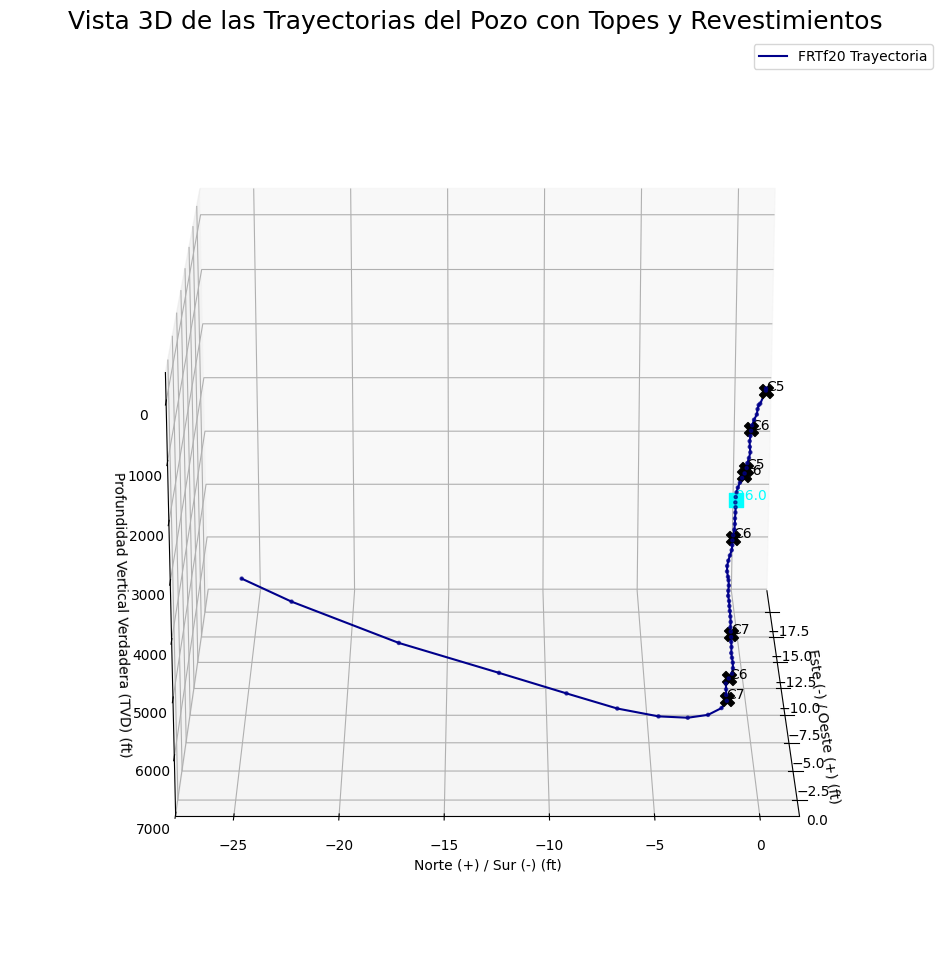

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np # Ensure numpy is imported for np.interp

# --- Configuración de Pozos para Graficar en esta celda ---
# Define aquí el nombre del pozo o pozos que quieres incluir en esta gráfica.
# Por ejemplo: wells_to_plot_this_cell = ['FRUf19', 'FRUf19y']
# Por defecto, grafica todos los pozos disponibles en df_all_surveys.
wells_to_plot_this_cell = ['FRTf20']

# --- Preparación del DataFrame para esta celda ---
df_current_plot = None
if 'df_all_surveys' in locals() and df_all_surveys is not None and not df_all_surveys.empty:
    if 'WELL_NAME' in df_all_surveys.columns:
        if wells_to_plot_this_cell: # Si se seleccionan pozos específicos
            df_current_plot = df_all_surveys[df_all_surveys['WELL_NAME'].isin(wells_to_plot_this_cell)].copy()
        else: # Si la lista está vacía o no se especifican pozos, graficar todos los pozos disponibles
            df_current_plot = df_all_surveys.copy()
        if df_current_plot.empty and wells_to_plot_this_cell: # Si se seleccionaron pozos pero no se encontraron
            print(f"Advertencia: Ninguno de los pozos seleccionados '{wells_to_plot_this_cell}' fue encontrado en los datos. No se generará el gráfico.")
            df_current_plot = None # Asegurar que es None si no hay datos
        elif df_current_plot.empty: # Si df_all_surveys estaba vacío
            print("Advertencia: 'df_all_surveys' está vacío. No se pueden generar los gráficos.")
            df_current_plot = None
    else:
        print("Advertencia: La columna 'WELL_NAME' no se encuentra en 'df_all_surveys'. Se intentará graficar todos los datos disponibles sin filtrar por pozo.")
        df_current_plot = df_all_surveys.copy()
else:
    print("Error: 'df_all_surveys' no está cargado o está vacío. No se pueden generar los gráficos.")


# Variables para controlar el ángulo de rotación de la cámara (ajusta estos valores)
elevation_angle = 20  # Ángulo de elevación en grados (vertical)
azimuth_angle = -0  # Ángulo de azimut en grados (horizontal)

# Variables para limitar el rango de profundidad (TVD) en el gráfico 3D
# Estos valores se inicializan de forma segura, pero se recalcularán si df_current_plot es válido.
min_tvd_limit = 0
max_tvd_limit = 21000

if df_current_plot is not None and not df_current_plot.empty:
    if 'TVD (ft)' in df_current_plot.columns:
        min_tvd_limit = df_current_plot['TVD (ft)'].min() * 0.9
        max_tvd_limit = df_current_plot['TVD (ft)'].max() * 1.1
    else:
        print("Advertencia: La columna 'TVD (ft)' no se encuentra en df_current_plot. Usando límites de TVD por defecto.")


if df_current_plot is not None and 'NS_ft' in df_current_plot.columns and 'EW_ft' in df_current_plot.columns and 'TVD (ft)' in df_current_plot.columns and not df_current_plot.empty:
    fig = plt.figure(figsize=(12, 14)) # Aumentar la altura del gráfico
    ax = fig.add_subplot(111, projection='3d')

    unique_wells = df_current_plot['WELL_NAME'].unique()
    # Define una lista de colores oscuros preferidos para los primeros pozos.
    preferred_dark_colors = ['darkblue', 'darkred', 'darkgreen', 'purple', 'brown', 'teal', 'darkgoldenrod', 'indigo', 'maroon', 'darkslategray']

    colors_for_plotting = []
    for i, well_name in enumerate(unique_wells):
        if i < len(preferred_dark_colors):
            colors_for_plotting.append(preferred_dark_colors[i])
        else:
            # Para pozos más allá de la lista predefinida, usa un colormap con sesgo hacia tonos más oscuros.
            cmap_val = (i - len(preferred_dark_colors)) / (len(unique_wells) - len(preferred_dark_colors) + 1e-6) # Normalizar el índice
            colors_for_plotting.append(plt.cm.get_cmap('gist_ncar')(cmap_val * 0.6 + 0.1)) # Ajustar el rango para ser más oscuro

    for i, well_name in enumerate(unique_wells):
        df_well = df_current_plot[df_current_plot['WELL_NAME'] == well_name].copy() # Use .copy() to avoid SettingWithCopyWarning

        # Filter df_well by TVD limits
        df_well_filtered = df_well[(df_well['TVD (ft)'] >= min_tvd_limit) & (df_well['TVD (ft)'] <= max_tvd_limit)]

        color = colors_for_plotting[i]
        # Plot la trayectoria del pozo en 3D
        ax.plot(df_well_filtered['EW_ft'], df_well_filtered['NS_ft'], df_well_filtered['TVD (ft)'], color=color, label=f'{well_name} Trayectoria')
        # Add small points at each data depth for the trajectory
        ax.scatter(df_well_filtered['EW_ft'], df_well_filtered['NS_ft'], df_well_filtered['TVD (ft)'], color=color, marker='.', s=20, alpha=0.7, label='_nolegend_')

    # Añadir topes al gráfico 3D
    if df_topes is not None and not df_topes.empty:
        # Ensure MD (ft) in df_current_plot is sorted for interpolation
        df_current_plot_sorted = df_current_plot.sort_values(by='MD (ft)').reset_index(drop=True)

        # Check if NS_ft, EW_ft, and TVD (ft) exist in df_current_plot_sorted
        if 'NS_ft' in df_current_plot_sorted.columns and 'EW_ft' in df_current_plot_sorted.columns and 'TVD (ft)' in df_current_plot_sorted.columns:
            df_topes_for_interp = df_topes.copy()
            if len(df_current_plot_sorted['MD (ft)']) > 1:
                df_topes_for_interp['NS_ft_interp'] = np.interp(df_topes_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['NS_ft'])
                df_topes_for_interp['EW_ft_interp'] = np.interp(df_topes_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['EW_ft'])
                df_topes_for_interp['TVD_interp'] = np.interp(df_topes_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['TVD (ft)'])

                # Filtrar topes por los límites de TVD
                df_topes_filtered = df_topes_for_interp[(df_topes_for_interp['TVD_interp'] >= min_tvd_limit) & (df_topes_for_interp['TVD_interp'] <= max_tvd_limit)]

                for _, row in df_topes_filtered.iterrows():
                    color_top_marker = 'darkred' if row['TOPS'] == 'KOP' else 'black'
                    ax.scatter(row['EW_ft_interp'], row['NS_ft_interp'], row['TVD_interp'], color=color_top_marker, marker='X', s=100, zorder=5, label='_nolegend_')
                    ax.text(row['EW_ft_interp'], row['NS_ft_interp'], row['TVD_interp'], row['TOPS'], color=color_top_marker, fontsize=10)
            else:
                print("Not enough survey data points in df_current_plot for tops interpolation. Skipping tops plotting.")
        else:
            print("NS_ft, EW_ft or TVD (ft) not found in df_current_plot_sorted for tops interpolation.")
    else:
        print("df_topes not loaded or is empty, skipping tops plotting.")

    # Añadir revestimientos al gráfico 3D
    if df_casings is not None and not df_casings.empty:
        # Ensure MD (ft) in df_current_plot is sorted for interpolation
        df_current_plot_sorted = df_current_plot.sort_values(by='MD (ft)').reset_index(drop=True)

        # Check if NS_ft, EW_ft, and TVD (ft) exist in df_current_plot_sorted
        if 'NS_ft' in df_current_plot_sorted.columns and 'EW_ft' in df_current_plot_sorted.columns and 'TVD (ft)' in df_current_plot_sorted.columns:
            df_casings_for_interp = df_casings.copy()
            if len(df_current_plot_sorted['MD (ft)']) > 1:
                df_casings_for_interp['NS_ft_interp'] = np.interp(df_casings_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['NS_ft'])
                df_casings_for_interp['EW_ft_interp'] = np.interp(df_casings_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['EW_ft'])
                df_casings_for_interp['TVD_interp'] = np.interp(df_casings_for_interp['MD (ft)'], df_current_plot_sorted['MD (ft)'], df_current_plot_sorted['TVD (ft)'])

                # Filtrar revestimientos por los límites de TVD
                df_casings_filtered = df_casings_for_interp[(df_casings_for_interp['TVD_interp'] >= min_tvd_limit) & (df_casings_for_interp['TVD_interp'] <= max_tvd_limit)]

                for _, row in df_casings_filtered.iterrows():
                    ax.scatter(row['EW_ft_interp'], row['NS_ft_interp'], row['TVD_interp'], color='cyan', marker='s', s=100, zorder=5, label='_nolegend_')
                    ax.text(row['EW_ft_interp'], row['NS_ft_interp'], row['TVD_interp'], row['SECTION_NAME'], color='cyan', fontsize=10)
            else:
                print("Not enough survey data points in df_current_plot for casings interpolation. Skipping casings plotting.")
        else:
            print("NS_ft, EW_ft or TVD (ft) not found in df_current_plot_sorted for casings interpolation.")
    else:
        print("df_casings not loaded or is empty, skipping casings plotting.")

    ax.set_xlabel('Este (-) / Oeste (+) (ft)')
    ax.set_ylabel('Norte (+) / Sur (-) (ft)')
    ax.set_zlabel('Profundidad Vertical Verdadera (TVD) (ft)')
    ax.set_title('Vista 3D de las Trayectorias del Pozo con Topes y Revestimientos', fontsize=18)

    # Invertir el eje Z (TVD) para que la profundidad aumente hacia abajo
    ax.invert_zaxis()

    # Ajustar el ángulo de visión de la cámara
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)

    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No se pueden generar el gráfico 3D. Asegúrate de que df_current_plot esté cargado, no esté vacío y las columnas 'NS_ft', 'EW_ft' y 'TVD (ft)' existan (posiblemente debido a que los pozos seleccionados no existen).")